In [12]:
import pandas as pd
import os

data_path = r'C:\Users\astra\Downloads\dataset2_large_scale_yield\dataset2_large_scale_yield'
# List all Parquet files in that folder
parquet_files = [f for f in os.listdir(data_path) if f.endswith('.parquet')]
print("Parquet files found:", parquet_files)

# Read and combine
df_list = [pd.read_parquet(os.path.join(data_path, f)) for f in parquet_files]
full_df = pd.concat(df_list, ignore_index=True)

# Preview
print(f"Loaded {len(parquet_files)} files.")
print(f"Combined shape: {full_df.shape}")
full_df.head()


Parquet files found: ['Badgingarra.parquet', 'Balaklava.parquet', 'Carnamah.parquet', 'Ceduna.parquet', 'Cummins.parquet', 'Gatton.parquet', 'Katanning.parquet', 'LakeGrace.parquet', 'Longerenong.parquet', 'Meandarra.parquet', 'Merriwagga.parquet', 'Mullewa.parquet', 'Narrabri.parquet', 'Pinnaroo.parquet', 'Roma.parquet', 'Urana.parquet', 'WaggaWagga.parquet', 'Waikerie.parquet', 'Walpeup.parquet', 'Wellington.parquet']
Loaded 20 files.
Combined shape: (6024041, 24)


,SiteName,Longitude,Latitude,State,WheatRegion,CultivarName,Year,Date,DOY,ZadokStage,...,TotalLeafN,GreenLeafWt,TotalLeafWt,Biomass,Yield,Radn,Rain,MaxT,MinT,TT
0,Badgingarra,115.54,-30.34,WA,WA3,Adv08_0008,2001.0,2001-06-02 12:00:00+00:00,153.0,0.000000,...,0.000000,0.00000,0.00000,0.00000,0.0,11.4,0.0,19.0,8.0,13.5
1,Badgingarra,115.54,-30.34,WA,WA3,Adv08_0008,2001.0,2001-06-03 12:00:00+00:00,154.0,5.630435,...,0.000004,0.00006,0.00006,0.00006,0.0,11.7,0.4,19.0,10.0,14.5
2,Badgingarra,115.54,-30.34,WA,WA3,Adv08_0008,2001.0,2001-06-04 12:00:00+00:00,155.0,6.130435,...,0.000004,0.00006,0.00006,0.00006,0.0,8.0,0.2,14.0,9.0,11.5
3,Badgingarra,115.54,-30.34,WA,WA3,Adv08_0008,2001.0,2001-06-05 12:00:00+00:00,156.0,6.500000,...,0.000004,0.00006,0.00006,0.00006,0.0,13.5,0.6,14.0,3.0,8.5
4,Badgingarra,115.54,-30.34,WA,WA3,Adv08_0008,2001.0,2001-06-06 12:00:00+00:00,157.0,6.869565,...,0.000004,0.00006,0.00006,0.00006,0.0,10.5,0.0,13.0,4.0,8.5


In [13]:
# Ensure 'Date' is proper datetime format
full_df['Date'] = pd.to_datetime(full_df['Date'], errors='coerce')

# Harvest Index (avoid divide-by-zero)
full_df['HarvestIndex'] = full_df['Yield'] / (full_df['Biomass'] + 1e-6)

# Total rainfall in the growing season per site per year
full_df['TotalRain'] = full_df.groupby(['SiteName', 'Year'])['Rain'].transform('sum')


In [14]:
# Summary of missing values
print(full_df.isna().sum())

# Simple imputation: fill missing numeric values with column mean
full_df.fillna(full_df.mean(numeric_only=True), inplace=True)


SiteName        0
Longitude       0
Latitude        0
State           0
WheatRegion     0
CultivarName    0
Year            0
Date            0
DOY             0
ZadokStage      0
CanopyHeight    0
GreenLAI        0
TotalLAI        0
GreenLeafN      0
TotalLeafN      0
GreenLeafWt     0
TotalLeafWt     0
Biomass         0
Yield           0
Radn            0
Rain            0
MaxT            0
MinT            0
TT              0
HarvestIndex    0
TotalRain       0
dtype: int64


In [15]:
# Summary stats for numeric columns
full_df.describe()


,Longitude,Latitude,Year,DOY,ZadokStage,CanopyHeight,GreenLAI,TotalLAI,GreenLeafN,TotalLeafN,...,TotalLeafWt,Biomass,Yield,Radn,Rain,MaxT,MinT,TT,HarvestIndex,TotalRain
count,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,...,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06,6.024041e+06
mean,1.372894e+02,-3.248064e+01,2.010452e+03,2.317625e+02,3.972835e+01,5.951701e+02,1.340811e+00,2.220822e+00,2.199789e+00,2.555872e+00,...,9.828902e+01,3.024211e+02,4.287524e+01,1.518072e+01,1.172584e+00,2.033310e+01,6.924075e+00,1.308850e+01,6.289545e-02,1.789683e+04
std,1.260319e+01,2.940643e+00,5.768207e+00,4.936220e+01,2.652573e+01,3.774114e+02,1.416140e+00,1.792778e+00,2.310793e+00,2.255623e+00,...,8.048378e+01,3.046643e+02,9.332182e+01,6.695066e+00,3.746003e+00,5.673839e+00,4.428010e+00,3.489714e+00,1.262763e-01,8.422569e+03
min,1.155100e+02,-3.667000e+01,2.001000e+03,1.400000e+02,0.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,6.300000e+00,-5.500000e+00,2.890539e+00,0.000000e+00,2.192000e+03
25%,1.334200e+02,-3.512000e+01,2.005000e+03,1.890000e+02,1.475047e+01,2.000000e+02,6.518463e-02,2.905329e-01,1.658675e-01,6.733983e-01,...,1.585141e+01,1.662057e+01,0.000000e+00,1.020000e+01,0.000000e+00,1.610000e+01,3.900000e+00,1.045000e+01,0.000000e+00,1.177500e+04
50%,1.409100e+02,-3.369000e+01,2.010000e+03,2.310000e+02,3.237443e+01,7.083791e+02,8.439506e-01,2.299535e+00,1.481940e+00,2.048157e+00,...,9.409284e+01,2.273412e+02,0.000000e+00,1.390000e+01,0.000000e+00,1.920000e+01,6.700000e+00,1.285000e+01,0.000000e+00,1.674960e+04
75%,1.474600e+02,-3.026000e+01,2.015000e+03,2.730000e+02,6.680719e+01,9.963888e+02,2.383587e+00,3.597524e+00,3.618916e+00,3.905113e+00,...,1.534422e+02,5.058318e+02,6.845988e+00,2.000000e+01,2.000000e-01,2.360000e+01,9.700000e+00,1.573800e+01,1.349690e-02,2.260650e+04
max,1.523300e+02,-2.655000e+01,2.020000e+03,3.640000e+02,9.000000e+01,1.000000e+03,9.101182e+00,9.215409e+00,1.485882e+01,1.487618e+01,...,5.185337e+02,1.607205e+03,6.665399e+02,3.500000e+01,1.706000e+02,4.770000e+01,2.910000e+01,2.480456e+01,5.458435e-01,5.718890e+04


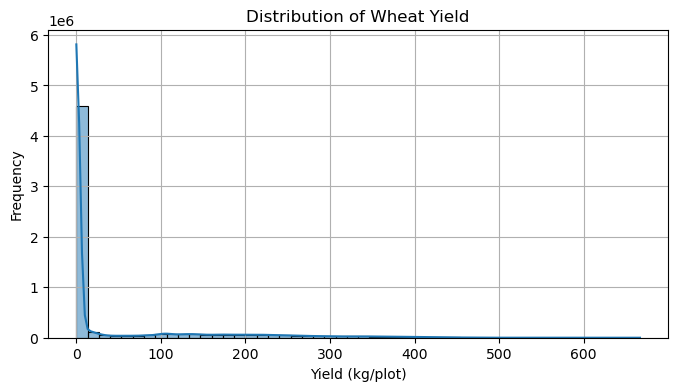

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(full_df['Yield'], kde=True, bins=50)
plt.title("Distribution of Wheat Yield")
plt.xlabel("Yield (kg/plot)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Biomass', y='Yield', data=full_df, alpha=0.1)
plt.title("Biomass vs Yield")
plt.xlabel("Biomass")
plt.ylabel("Yield")
plt.grid(True)
plt.show()


In [ ]:
# Choose the most relevant continuous variables
variables = ['Yield', 'Biomass', 'GreenLeafN', 'CanopyHeight', 'Radn', 'Rain', 'MaxT', 'MinT', 'HarvestIndex', 'TotalRain']

plt.figure(figsize=(10, 8))
corr_matrix = full_df[variables].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
mean_yield_by_site = full_df.groupby('SiteName')['Yield'].mean().sort_values()

plt.figure(figsize=(12, 5))
mean_yield_by_site.plot(kind='bar', color='mediumseagreen')
plt.title("Average Yield by Location")
plt.ylabel("Mean Yield (kg/plot)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
features = [
    'Biomass', 'GreenLeafN', 'CanopyHeight', 'Radn', 'Rain',
    'MaxT', 'MinT', 'HarvestIndex', 'TotalRain'
]
X = full_df[features]
y = full_df['Yield']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize (scaling improves MLP; optional for trees)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model, X, y, model_name):
    r2_scores = []
    mae_scores = []
    rmse_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[test_index]
        y_train, y_val = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        r2_scores.append(r2_score(y_val, y_pred))
        mae_scores.append(mean_absolute_error(y_val, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    print(f"📊 {model_name} Cross-Validation Results (5-Fold):")
    print(f"Avg R²   : {np.mean(r2_scores):.3f}")
    print(f"Avg MAE  : {np.mean(mae_scores):.3f}")
    print(f"Avg RMSE : {np.mean(rmse_scores):.3f}\n")


In [ ]:
# Define models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

# ✅ Call cross-validation on each
cross_validate_model(rf, X, y, "Random Forest")
cross_validate_model(xgb, X, y, "XGBoost")


In [ ]:
import shap

# Create TreeExplainer and calculate SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

# Plot SHAP feature importances
shap.summary_plot(shap_values, X_train, plot_type="bar")
